# Gaussian mixtures: the basics

In this notebook we sort apples into groups using a **Gaussian mixture model**. We start right from the beginning, with what a **bell curve** is.

We will:

1. Weigh some apples and see the **hill shape** they make
2. Describe that hill with **two numbers**: its middle and its width
3. Mix two kinds of apple together and lose the labels
4. Use a Gaussian mixture model to find the **two hidden hills**
5. Give each apple a **percentage** for each group

Run each cell in order with **Shift + Enter**.

## Key words

| Word | Meaning |
|---|---|
| **Bell curve** | The smooth hill shape a pile of measurements makes. Also called a **normal distribution** or a **Gaussian** |
| **Middle** | Where the peak of the hill is: the average |
| **Width** | How spread out the values are |
| **Mixture** | Several bell curves mixed together |

## Step 1: Setting up

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

import warnings
warnings.filterwarnings("ignore")   # hide technical warnings so the output is easier to read

rng = np.random.default_rng(4)      # fixed seed, so everyone gets the same apples

## Step 2: Weigh 120 apples of one kind

We make up the weights of 120 apples of the same kind. Here are the first ten, in grams.

In [2]:
kind_1 = rng.normal(150, 12, 120)     # 120 apples, around 150 g
kind_2 = rng.normal(190, 16, 80)      # 80 apples of another kind, around 190 g (used later)

print(kind_1[:10].round(1))

[142.2 147.9 170.  157.9 130.3 149.9 142.5 151.8 130.7 152.9]


A list of numbers is hard to read. Let's **stack** the apples instead: we split the weights into 5 g ranges and count how many apples fall in each one. Each bar shows how many apples there are of about that weight.

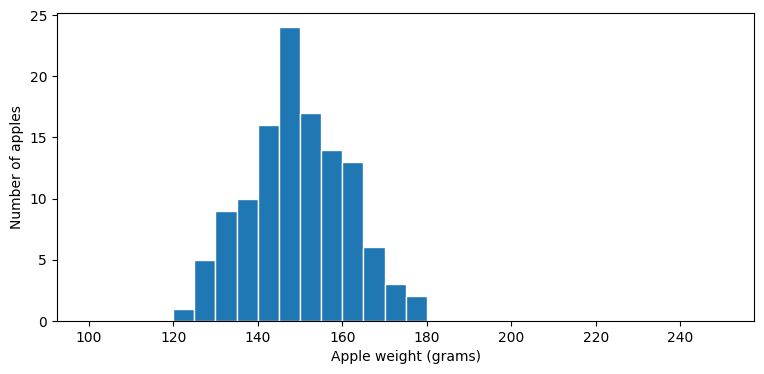

In [3]:
bins = np.arange(100, 255, 5)          # ranges: 100-105 g, 105-110 g, ...

plt.figure(figsize=(9, 4))
plt.hist(kind_1, bins=bins, color="tab:blue", edgecolor="white")
plt.xlabel("Apple weight (grams)")
plt.ylabel("Number of apples")
plt.show()

**What shape do you see?**

- Lots of apples are near the **middle**.
- The further from the middle, the **fewer** apples there are.
- It is roughly the **same on both sides**.

This hill shape is called a **bell curve**, because it looks like the outline of a bell.

## Step 3: Two numbers describe the hill

Every bell curve is described by just two numbers:

- the **middle**: where the peak is (the average weight)
- the **width**: how spread out the weights are

In [4]:
middle = kind_1.mean()
width = kind_1.std()

print(f"Middle: {middle:.1f} g")
print(f"Width:  {width:.1f} g")

Middle: 149.6 g
Width:  11.8 g


Below is a function that draws a smooth bell curve from a middle and a width. You do not need to understand the formula inside it. Let's draw it over our apples.

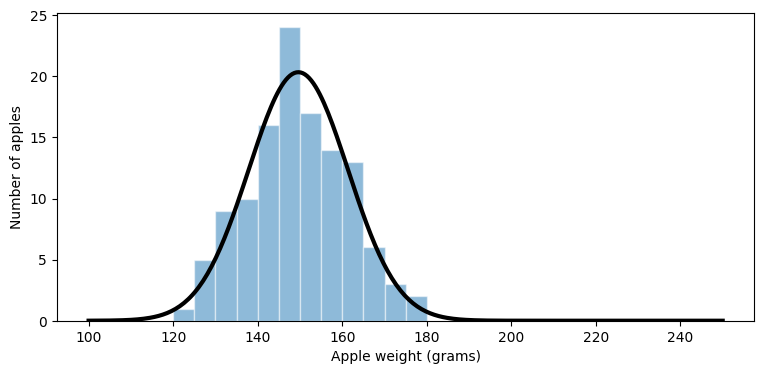

In [5]:
def bell(x, middle, width):
    return np.exp(-0.5 * ((x - middle) / width) ** 2) / (width * np.sqrt(2 * np.pi))

weights = np.linspace(100, 250, 300)

plt.figure(figsize=(9, 4))
plt.hist(kind_1, bins=bins, color="tab:blue", edgecolor="white", alpha=0.5)
plt.plot(weights, bell(weights, middle, width) * 120 * 5, color="black", linewidth=3)   # scaled to match the bars
plt.xlabel("Apple weight (grams)")
plt.ylabel("Number of apples")
plt.show()

The smooth curve follows the bars closely. Those two numbers, the middle and the width, are enough to describe the whole pile.

Here is what happens if we change the middle or the width.

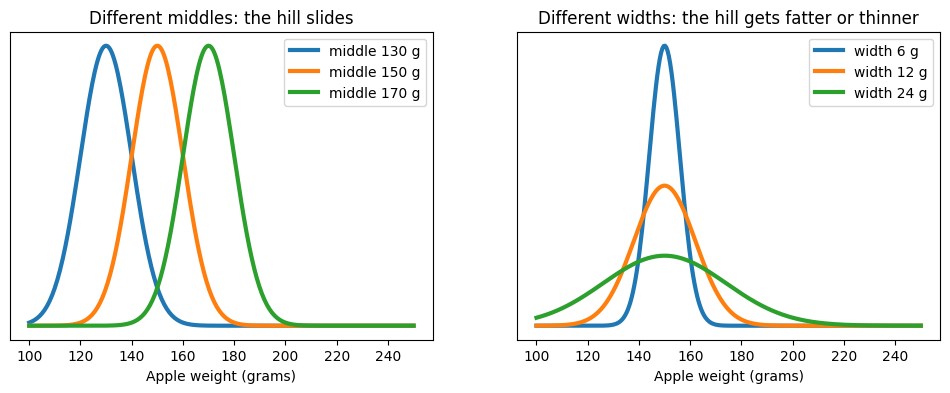

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for m in [130, 150, 170]:
    axes[0].plot(weights, bell(weights, m, 10), linewidth=3, label=f"middle {m} g")
axes[0].set_title("Different middles: the hill slides")
axes[0].legend()

for w in [6, 12, 24]:
    axes[1].plot(weights, bell(weights, 150, w), linewidth=3, label=f"width {w} g")
axes[1].set_title("Different widths: the hill gets fatter or thinner")
axes[1].legend()

for ax in axes:
    ax.set_xlabel("Apple weight (grams)")
    ax.set_yticks([])
plt.show()

## Step 4: Mix two kinds of apple together

Now someone tips **both** kinds of apple into one box: 120 of kind 1 and 80 of kind 2. Nobody wrote down which is which, so we only have the weights.

Apples in the box: 200


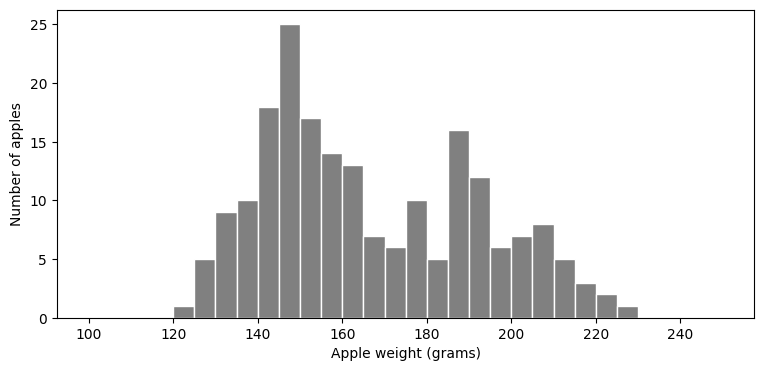

In [7]:
all_apples = np.concatenate([kind_1, kind_2])
print("Apples in the box:", len(all_apples))

plt.figure(figsize=(9, 4))
plt.hist(all_apples, bins=bins, color="grey", edgecolor="white")
plt.xlabel("Apple weight (grams)")
plt.ylabel("Number of apples")
plt.show()

**How many hills can you see?** There seem to be two: a tall one around 150 g and a lower one around 190 g. In the middle they overlap, so we cannot tell by eye which kind those apples are.

A **Gaussian mixture model** finds these hidden hills for us. The name just means:

- **Gaussian** = bell curve
- **Mixture** = several of them mixed together

## Step 5: Find the hidden hills

We tell the model to look for **2** hills. scikit-learn wants the data as a single column, so we use `reshape(-1, 1)`.

In [8]:
X = all_apples.reshape(-1, 1)

model = GaussianMixture(n_components=2, random_state=0)
model.fit(X)

# sort the two hills from lightest to heaviest, so hill 1 is always the lighter one
order = np.argsort(model.means_.ravel())
middles = model.means_.ravel()[order]
widths = np.sqrt(model.covariances_.ravel()[order])
sizes = model.weights_[order]

for i in range(2):
    print(f"Hill {i + 1}: middle {middles[i]:.0f} g, width {widths[i]:.0f} g, holds {sizes[i]:.0%} of the apples")

Hill 1: middle 149 g, width 11 g, holds 59% of the apples
Hill 2: middle 193 g, width 15 g, holds 41% of the apples


The model found two hills, very close to the two kinds we started with (around 150 g and 190 g). It was **never told** which apple was which. It worked it out from the shape of the pile.

Let's draw the two hills over the apples.

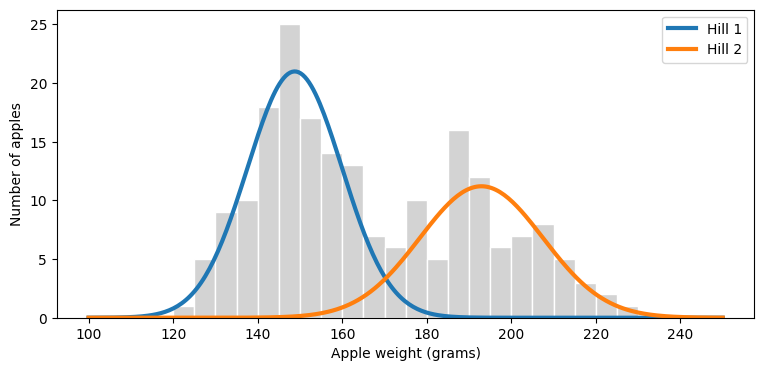

In [9]:
plt.figure(figsize=(9, 4))
plt.hist(all_apples, bins=bins, color="lightgrey", edgecolor="white")
plt.plot(weights, bell(weights, middles[0], widths[0]) * sizes[0] * 200 * 5, color="tab:blue", linewidth=3, label="Hill 1")
plt.plot(weights, bell(weights, middles[1], widths[1]) * sizes[1] * 200 * 5, color="tab:orange", linewidth=3, label="Hill 2")
plt.xlabel("Apple weight (grams)")
plt.ylabel("Number of apples")
plt.legend()
plt.show()

## Step 6: Which group is each apple?

For any apple, we look at **how tall each hill is** at its weight. The taller hill gets the bigger share. `predict_proba` gives these shares as percentages.

In [10]:
test_apples = np.array([[140.0], [170.0], [200.0]])
percentages = model.predict_proba(test_apples)[:, order]

for apple, (p1, p2) in zip(test_apples.ravel(), percentages):
    print(f"{apple:.0f} g apple:  hill 1 {p1:6.1%}   hill 2 {p2:6.1%}")

140 g apple:  hill 1  99.9%   hill 2   0.1%
170 g apple:  hill 1  51.8%   hill 2  48.2%
200 g apple:  hill 1   0.0%   hill 2 100.0%


- A **140 g** apple is almost certainly hill 1.
- A **200 g** apple is almost certainly hill 2.
- A **170 g** apple is about **50 / 50**. It sits where the two hills overlap, and the model honestly says it is not sure.

This is the big difference from **k-means**, which would put the 170 g apple 100% into one group with no warning that it was a close call.

In [11]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, n_init=10, random_state=0).fit(X)
print("K-means centres:", np.sort(kmeans.cluster_centers_.ravel()).round(0))
print("K-means puts the 170 g apple in the group with centre",
      kmeans.cluster_centers_[kmeans.predict([[170.0]])[0]].round(0)[0], "g, and gives no percentage")

K-means centres: [149. 194.]
K-means puts the 170 g apple in the group with centre 149.0 g, and gives no percentage


## Step 7: How well did it do?

Because we made up the apples, we know which kind each one really was. That lets us check the model. (With real data we usually would not know this.)

In [12]:
true_kind = np.array([1] * 120 + [2] * 80)

hill = model.predict(X)                       # most likely hill for each apple
hill = np.where(hill == order[0], 1, 2)       # name the lighter hill 1 and the heavier hill 2

correct = (hill == true_kind).sum()
print("Apples put in the right group:", correct, "out of", len(true_kind))

Apples put in the right group: 191 out of 200


Most apples are put in the right group. The few mistakes are apples in the overlap, where a heavy kind 1 apple and a light kind 2 apple really do weigh about the same.

## Summary

| Idea | What it means |
|---|---|
| Bell curve | A pile of measurements makes a hill: lots in the middle, fewer at the edges |
| Two numbers | Every bell curve has a middle and a width |
| Gaussian mixture | Finds several bell curves mixed together in the data |
| Percentages | Each point gets a % for each group, by comparing how tall the hills are |
| Unsure points | Points in the overlap get about 50 / 50, instead of being forced into one group |

## Things to try

1. In Step 6, add a **155 g** apple to `test_apples`. Before you run it, predict: which hill, and how sure will the model be?
2. In Step 2, move kind 2 closer by changing `190` to **170**. Run everything again. What happens to the hills, the percentages and the number of apples in the right group?
3. In Step 5, change `n_components=2` to **3**. What does the model do when you ask for more hills than there really are?

In [13]:
# Your experiments here